# Kleene's Theorem (Part 1)

## Introduction

After completing this chapter, you will be able to:

* Understand the statement of Kleene's Theorem.
* Create a DFA that recognizes the language generated by a given regular expression.

We'll be creating some directed graphs, so we'll import the libraries for doing so, as well as some libraries for displaying them. We'll also use our directed graph display function. We'll also want the intertools library later on.

We use these libraries to build and visualize the directed graphs we'll be using in this chapter:

| Package | Purpose |
|---|---|
| `io` | Basic library for handling input and output |
| `base64` | Manages special characters |
| `IPython` | Provides additional Python functionality |
| `graphviz` | General graph visualization |
| `itertools` | Tools for iterating through objects |

The cell below checks whether each package is already installed and installs
it automatically if not. This is safe to re-run; it only installs what is
missing.

**Outside Jupyter**, install once from the terminal:
```bash
pip install io base64 IPython graphviz itertools
```

In [1]:
# Install required Python packages using pip
import sys
import importlib.util
import subprocess

def install_if_missing(package):
    if importlib.util.find_spec(package) is None:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        print(f"{package} has been installed")
    else:
        print(f"{package} is already installed")

required_packages = ['io', 'base64', 'IPython', 'graphviz', 'itertools']
for package in required_packages:
    install_if_missing(package)

import io
import base64
from IPython.display import display, HTML
from graphviz import Digraph, Source
import itertools

io is already installed
base64 is already installed
IPython is already installed
graphviz is already installed
itertools is already installed


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Display Graph with Caption
#
# Running outside Jupyter:
#   python display_graph_with_caption.py
# ─────────────────────────────────────────────────────────────────────────────

def display_graph_with_caption(graph: Digraph, fig_num: str, title: str, alt_text: str, format: str = 'png'):
    """
    Takes a graphviz.Digraph object and displays it in a Jupyter Notebook cell
    as an accessible HTML image with a structured figure caption.

    Parameters:
    - graph (Digraph): The graphviz Digraph object to display.
    - fig_num (str): The figure number (e.g., "1", "3.1a") which is formatted as "Figure X". (UPDATED TO STRING)
    - title (str): The descriptive title for the figure caption.
    - alt_text (str): The full accessible description for screen readers.
    - format (str): The image format ('png' or 'svg' recommended). Defaults to 'png'.
    """
    if not isinstance(graph, Digraph):
        raise TypeError("The 'graph' parameter must be a graphviz.Digraph object.")

    # 1. Format Figure Number and Caption
    # fig_num is now used directly as a string
    figure_number_str = f"Figure {fig_num}"
    full_caption = f"<b>{figure_number_str}:</b> {title}"

    # 2. Get the raw binary image data using pipe()
    try:
        img_binary_data = graph.pipe(format=format)
    except Exception as e:
        print(f"Error generating graph image using pipe(): {e}")
        return

    # 3. Encode the binary data to Base64
    img_data = base64.b64encode(img_binary_data).decode('utf-8')

    # 4. Determine the mime type for the HTML
    mime_type = f"image/{format}"

    # 5. Construct the full accessible HTML block
    html_output = f"""
    <figure style="text-align: center; margin: 1em 0;">
        <img src="data:{mime_type};base64,{img_data}" alt="{alt_text}"
             style="max-width: 100%; height: auto; display: block; margin: 0 auto;" />
        <figcaption style="margin-top: 0.5em; font-size: 0.9em; color: #333;">
            {full_caption}
        </figcaption>
    </figure>
    """

    # 6. Display the HTML in the notebook
    display(HTML(html_output))

We'll also want to use our FA class from Chapter 3. Note we've added a *graph_size* attribute, which will be useful later when we want to display larger diagrams.

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# The FA class from Chapter 3.
#
# Running outside Jupyter:
#   python FA.py
# ─────────────────────────────────────────────────────────────────────────────

class FA:
    """
    Represents a Deterministic Finite Automaton (DFA) defined by a 5-tuple:
    (States, Alphabet, Transition_Function, Start_State, Accept_States).

    Includes methods for validation, graphical representation, and string processing.
    """
    def __init__(self, states, alphabet, transition_function, start_state, accept_states, graph_size=None):
        """Initializes the FA and performs validation."""
        self.states = set(states)
        self.alphabet = set(alphabet)
        # Transition function is a dictionary: (current_state, symbol) -> next_state
        self.transition_function = transition_function
        self.start_state = start_state
        self.accept_states = set(accept_states)

        # Store the size attribute (e.g., "8,5")
        self.graph_size = graph_size

        self.validate()

    def validate(self):
        """
        Ensures the FA structure is valid according to the formal definition (DFA):
        1. Start state is valid.
        2. Accept states are a subset of states.
        3. Transition function is total (defined for every state and symbol).
        4. Transitions map to valid states.
        """
        if self.start_state not in self.states:
            raise ValueError("Start state must be in states.")
        if not self.accept_states.issubset(self.states):
            raise ValueError("Accept states must be a subset of states.")

        # Ensure total transition function
        for state in self.states:
            for symbol in self.alphabet:
                if (state, symbol) not in self.transition_function:
                    raise ValueError(f"Missing transition for state '{state}' on symbol '{symbol}'.")

        # Ensure all transitions are to valid states and symbols
        for (state, symbol), next_state in self.transition_function.items():
            if state not in self.states or next_state not in self.states:
                raise ValueError(f"Invalid transition: ({state}, {symbol}) → {next_state}")
            if symbol not in self.alphabet:
                raise ValueError(f"Symbol '{symbol}' not in alphabet.")

    def build_graph(self):
        """
        Generates the graphviz Digraph object for the state diagram.
        Uses standard conventions (incoming arrow for start, double circle for accept).
        """
        dot = Digraph()
        dot.attr(rankdir='LR')

        # Apply the size attribute if it was set
        if self.graph_size:
            dot.attr(size=self.graph_size)

        # Start state pointer
        dot.node('', shape='none')
        dot.edge('', self.start_state)

        # Define nodes and their shapes
        for state in self.states:
            shape = 'doublecircle' if state in self.accept_states else 'circle'
            dot.node(state, label=str(state), shape=shape)

        # Group transitions by (src, dst) to show multiple labels on one edge
        transition_groups = {}
        for (src, symbol), dst in self.transition_function.items():
            key = (src, dst)
            if key not in transition_groups:
                transition_groups[key] = []
            transition_groups[key].append(symbol)

        # Draw edges
        for (src, dst), symbols in transition_groups.items():
            label = ",".join(sorted(symbols))
            dot.edge(str(src), str(dst), label=label)

        return dot

    def show(self, fig_num=None, title=None, alt_text="Finite automaton diagram.", format='png'):
        """
        Generates and displays the FA digraph as an accessible HTML image.
        Uses fig_num, title, and alt_text for captioning and accessibility.

        Parameters:
        - fig_num (str): Figure number (e.g., "Figure 3.2").
        - title (str): Title of the figure.
        - alt_text (str): Accessible description for screen readers.
        - format (str): Output format for graphviz ('png', 'svg', etc.).
        """
        graph = self.build_graph()

        # Get the raw image data using pipe()
        img_binary_data = graph.pipe(format=format)
        img_data = base64.b64encode(img_binary_data).decode('utf-8')

        # Construct the caption content
        caption_content = ""
        if fig_num or title:
            caption_parts = []
            if fig_num:
                caption_parts.append(f"<b>Figure {fig_num}:</b>")
            if title:
                caption_parts.append(title)

            caption_content = " ".join(caption_parts)

        # Determine the mime type for the HTML
        mime_type = f"image/{format}"

        # Construct the full HTML block
        html_output = f"""
        <figure style="text-align: center; margin: 1em 0;">
            <img src="data:{mime_type};base64,{img_data}" alt="{alt_text}"
                 style="max-width: 100%; height: auto; display: block; margin: 0 auto;" />

            {f'<figcaption style="margin-top: 0.5em; font-size: 0.9em; color: #333;">{caption_content}</figcaption>' if caption_content else ''}
        </figure>
        """
        display(HTML(html_output))

    def accepts(self, input_string):
        """
        Determines whether the input string is accepted by the finite automaton.
        """
        current_state = self.start_state
        for symbol in input_string:
            if symbol not in self.alphabet:
                raise ValueError(f"Symbol '{symbol}' not in FA alphabet.")
            current_state = self.transition_function[(current_state, symbol)]

        return current_state in self.accept_states

    def trace(self, input_string):
        """
        Traces the sequence of states visited by the FA as it processes an input string.
        Returns a list of states, including the initial state.
        """
        trace = [self.start_state]
        current_state = self.start_state
        for symbol in input_string:
            if (current_state, symbol) not in self.transition_function:
                # Should not happen if validate() passed, but included for safety
                trace.append(None)
                break
            current_state = self.transition_function[(current_state, symbol)]
            trace.append(current_state)

        return trace

## 1. Kleene's Theorem

We have so far seen three primary ways of defining a language:

1. The set of all strings over an alphabet recognized by a DFA.
2. The set of all strings over an alphabet recognized by an NFA.
3. The set of all strings generated by a regular expression.

In Chapter 4, we proved that for any NFA there is a DFA that recognizes the same language, and so the sets of languages we can define using the first two methods are equal. *Kleene's Theorem* states that the sets of languages we can define using all three methods are equal. This means for every regular expression, there is a DFA that recognizes exactly the language generated by that regular expression, and for every NFA, there is a regular expression that generates exactly the language recognized by the NFA.

In this chapter we'll prove the first of these containments - that for every regular expression there is a DFA that recognizes exactly the language generated by the regular expression. In the next chapter we'll prove the second containment, and in doing so prove the equality of all three methods.

## 2. Generated by a Regular Expression $\subseteq$ Recognized by a DFA

We will now prove that any language generated by a regular expression can be recognized by a DFA. This proof will be constructive, and the algorithm for the construction is known as *Thompson's construction*, after the computer scientist Ken Thompson.

First, we recall the definition of a regular expression from Chapter 2:

---

**Definition** - The set of *regular expressions* over an alphabet $\Sigma$ is defined by the rules:

* **Rule 1**: Every letter of $\Sigma$ can be made into a regular expression by writing it in boldface; $\boldsymbol{\lambda}$ (the empty string) is a regular expression.

* **Rule 2**: If $\textbf{r}_{1}$ and $\textbf{r}_{2}$ are regular expressions, then so are:

  * $(\textbf{r}_{1})$
  * $\textbf{r}_{1}$ $\textbf{r}_{2}$
  * $\textbf{r}_{1}$ + $\textbf{r}_{2}$
  * $\textbf{r}_{1}^{*}$

* **Rule 3**: Nothing else is a regular expression.

---

So, in order to prove the languages generated by regular expressions can all be recognized by DFAs, we must first prove that all languages generated by Rule 1 can be recognized by DFAs (easy), and then demonstrate how we handle the operations from Rule 2, namely unions, products, and Kleene stars (harder). If we can do this, then according to Rule 3 we're done!

This proof will cover everything you need to know, but will be a bit less formal that you'd see in a precise writeup, and will lean on demonstrations. We'll assume in each demonstration that our alphabet is $\Sigma = \{a,b\}$. It should be straightforward how things would generalize to larger alphabets.

### 2.1 The Empty String and Single Letters

A DFA that recognizes just the empty string is:

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# A DFA accepting only the empty string.
# ─────────────────────────────────────────────────────────────────────────────

empty = Digraph()
empty.attr(rankdir='LR') # This specifies the diagram should go left to right

# Start arrow
empty.node('', shape='none')
empty.edge('', 'start state')

# States
with empty.subgraph() as start:
  start.attr(rank='same')
  start.node('start state', shape='doublecircle')
with empty.subgraph() as fail:
  fail.attr(rank='same')
  fail.node('fail state', shape='circle')

# Transitions
empty.edge('start state', 'fail state', label='a,b')
empty.edge('fail state', 'fail state', label='a,b')


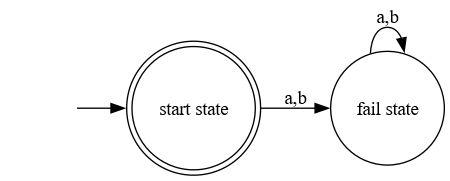

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Displays the state diagram of a DFA accepting only the empty string.
# ─────────────────────────────────────────────────────────────────────────────

fig_num_1 = "1"
title_1 = "Finite Automaton Accepting the Empty String."
alt_text_1 = (
    "A deterministic finite automaton (DFA) with two states: 'start state' and 'fail state', over the alphabet {a, b}. "
    "The 'start state' is both the initial state and an accept state (double circle). "
    "The 'fail state' is a non-accepting trap state (single circle). "
    "From the 'start state': Any input ('a' or 'b') transitions to the 'fail state'. "
    "The 'fail state' self-loops to itself on any input ('a' or 'b'). "
    "This machine accepts only the empty string (lambda), as any non-empty input leads immediately to the fail state."
)

display_graph_with_caption(empty, fig_num_1, title_1, alt_text_1)

A DFA that accepts only a string of one letter (say $a$) is:

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# A DFA accepting only a single letter. The letter "a" in this case.
# ─────────────────────────────────────────────────────────────────────────────

letter = Digraph()
letter.attr(rankdir='LR') # This specifies the diagram should go left to right

# Start arrow
letter.node('', shape='none')
letter.edge('', 'start state')

# States
with letter.subgraph() as fail:
  fail.attr(rank='same')
  fail.node('start state', shape='circle')
  fail.node('fail state', shape='circle')
with letter.subgraph() as success:
  success.attr(rank='same')
  success.node('accept state', shape='doublecircle')

# Transitions
letter.edge('start state', 'accept state', label='a')
letter.edge('start state', 'fail state', label='b')
letter.edge('accept state', 'fail state', label='a,b')
letter.edge('fail state', 'fail state', tailport='w', headport='w', label='a,b')


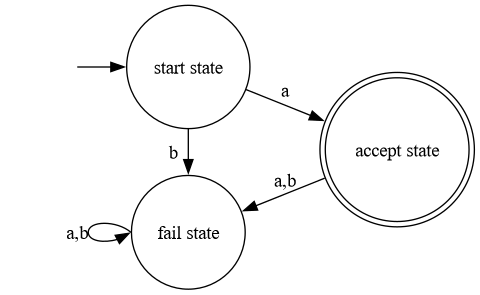

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Displays the state diagram of a DFA accepting only a single letter.
# ─────────────────────────────────────────────────────────────────────────────

fig_num_2 = "2"
title_2 = "Finite Automaton Accepting the Single Letter 'a'."
alt_text_2 = (
    "A deterministic finite automaton (DFA) with three states: 'start state', 'accept state', and 'fail state'. "
    "The 'start state' is the initial state (single circle). The 'accept state' is the final state (double circle). "
    "Transitions are as follows: "
    "From the 'start state': Input 'a' transitions to the 'accept state'; Input 'b' transitions to the 'fail state'. "
    "From the 'accept state': Any input ('a' or 'b') transitions to the 'fail state'. "
    "The 'fail state' is a non-accepting trap state that self-loops to itself on both 'a' and 'b'. "
    "This machine accepts only the single-character string 'a' and rejects all other strings."
)

# Use the global utility function
display_graph_with_caption(letter, fig_num_2, title_2, alt_text_2)

### 2.2 Unions

To take the union of two DFAs, say $DFA_{1} + DFA_{2}$, you need to create another finite automata $DFA_{3}$, where the nodes of $DFA_{3}$ are products of nodes from $DFA_{1}$ and $DFA_{2}$, and the transitions go between these products. The start state is the product of both start states, and the accept states are those where one or the other (but not necessarily both) nodes in the product are final states.

Let's go over this with an example. Suppose the DFA below is $DFA_{1}$:

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# DFA accepting words ending with an "a".
# ─────────────────────────────────────────────────────────────────────────────

dfa1 = FA(
    states={'x1', 'x2'},
    alphabet={'a', 'b'},
    transition_function={
        ('x1', 'a'): 'x2',
        ('x1', 'b'): 'x1',
        ('x2', 'a'): 'x2',
        ('x2', 'b'): 'x1'
    },
    start_state='x1',
    accept_states={'x2'}
)


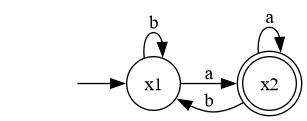

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Display the state diagram of a DFA accepting words ending with an "a".
# ─────────────────────────────────────────────────────────────────────────────

fig_num_3 = "3"
title_3 = "DFA accepting words ending with 'a'"
alt_text_3 = (
        "A deterministic finite automaton (DFA) with two states, x1 and x2, over the alphabet {a, b}. "
        "State x1 is the initial, non-accepting state. State x2 is the accepting state (double circle). "
        "Transitions are defined to accept strings ending in 'a': "
        "From state x1, input 'a' transitions to the accepting state x2, and input 'b' self-loops to x1. "
        "From state x2 (accepting), input 'a' self-loops to x2, maintaining acceptance, and input 'b' transitions back to the non-accepting state x1. "
        "The DFA accepts all strings that end with the character 'a'."
    )

dfa1.show(fig_num_3, title_3, alt_text_3)

The DFA below is $DFA_{2}$:

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# DFA accepting words that contain the substring "ab".
# ─────────────────────────────────────────────────────────────────────────────

dfa2 = FA(
    states={'y1', 'y2', 'y3'},
    alphabet={'a', 'b'},
    transition_function={
        ('y1', 'a'): 'y2',
        ('y1', 'b'): 'y1',
        ('y2', 'a'): 'y2',
        ('y2', 'b'): 'y3',
        ('y3', 'a'): 'y3',
        ('y3', 'b'): 'y3'
    },
    start_state='y1',
    accept_states={'y3'}
)


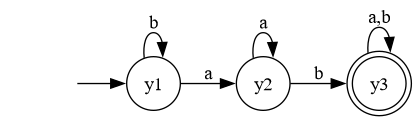

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# State diagram of a DFA accepting words containing "ab".
# ─────────────────────────────────────────────────────────────────────────────

fig_num_4 = "4"
title_4 = "DFA accepting words with an 'a' followed at some point by a 'b' (contains 'ab')"
alt_text_4 = (
        "A deterministic finite automaton (DFA) with three states, y1, y2, and y3, over the alphabet {a, b}. "
        "State y1 is the initial state. State y3 is the single accepting state (double circle). "
        "The DFA recognizes strings containing the substring 'ab'. "
        "From y1: Input 'a' transitions to y2; input 'b' self-loops to y1. "
        "From y2: Input 'a' self-loops to y2; input 'b' transitions to the accepting state y3. "
        "From y3 (accepting): Both 'a' and 'b' self-loop to y3. This ensures that once 'ab' is seen, the string remains accepted."
    )

dfa2.show(fig_num_4, title_4, alt_text_4)

The union of these two DFAs, $DFA_{3}$, would be:

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# DFA that is the union of dfa1 and dfa2 above.
# ─────────────────────────────────────────────────────────────────────────────

dfa3 = FA(
    states={'x1,y1', 'x2,y1', 'x1,y2', 'x2,y2', 'x1,y3', 'x2,y3'},
    alphabet={'a', 'b'},
    transition_function={
        ('x1,y1', 'a'): 'x2,y2',
        ('x1,y1', 'b'): 'x1,y1',

        ('x2,y1', 'a'): 'x2,y2',
        ('x2,y1', 'b'): 'x1,y1',

        ('x1,y2', 'a'): 'x2,y2',
        ('x1,y2', 'b'): 'x1,y3',

        ('x2,y2', 'a'): 'x2,y2',
        ('x2,y2', 'b'): 'x1,y3',

        ('x1,y3', 'a'): 'x2,y3',
        ('x1,y3', 'b'): 'x1,y3',

        ('x2,y3', 'a'): 'x2,y3',
        ('x2,y3', 'b'): 'x1,y3'
    },
    start_state='x1,y1',
    accept_states={'x2,y1', 'x2,y2', 'x1,y3', 'x2,y3'}
)


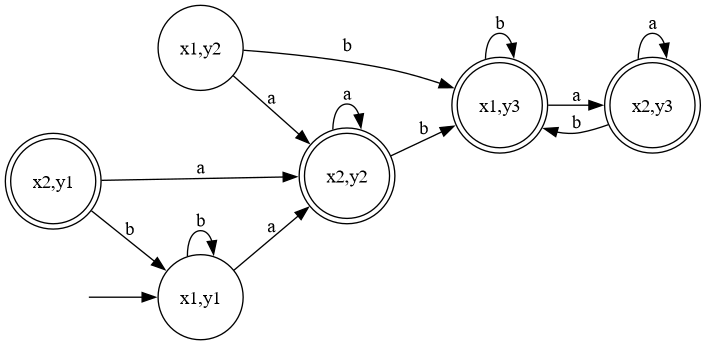

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# State diagram of DFA that is the union of dfa1 and dfa2 above.
# ─────────────────────────────────────────────────────────────────────────────

fig_num_5 = "5"
title_5 = "The union of DFA1 and DFA2 (DFA3 - Full Product Automaton)"
alt_text_5 = (
        "A complex Deterministic Finite Automaton (DFA) constructed as the product of two smaller DFAs. "
        "The machine has six composite states, labeled with pairs (xI, yJ), over the alphabet {a, b}. "
        "The initial state is x1,y1. "
        "The machine accepts the union of the two component languages: strings that end in 'a' OR contain the substring 'ab'. "
        "The accepting states (double circles) are all those where the x-component is x2 OR the y-component is y3. "
        "The transitions show the combined logic: for every input, the x-component updates its end-in-'a' status, "
        "and the y-component updates its contains-'ab' status simultaneously."
    )

dfa3.show(fig_num_5, title_5, alt_text_5)

Now, this would be correct, but we can note there's no way to reach $(x2,y1)$ or $(x1,y2)$ from the start state $(x1,y1)$. We can eliminate them and have an equivalent DFA:

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Simplified DFA equivalent to the union of dfa1 and dfa2 above.
# ─────────────────────────────────────────────────────────────────────────────

dfa3_reduced = FA(
    states={'x1,y1', 'x2,y2', 'x1,y3', 'x2,y3'},
    alphabet={'a', 'b'},
    transition_function={
        ('x1,y1', 'a'): 'x2,y2',
        ('x1,y1', 'b'): 'x1,y1',

        ('x2,y2', 'a'): 'x2,y2',
        ('x2,y2', 'b'): 'x1,y3',

        ('x1,y3', 'a'): 'x2,y3',
        ('x1,y3', 'b'): 'x1,y3',

        ('x2,y3', 'a'): 'x2,y3',
        ('x2,y3', 'b'): 'x1,y3'
    },
    start_state='x1,y1',
    accept_states={'x2,y2', 'x1,y3', 'x2,y3'}
)


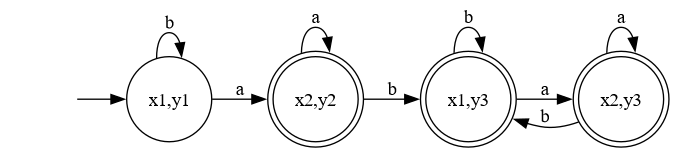

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# State diagram of simplified DFA equivalent to the union of 
# dfa1 and dfa2 above.
# ─────────────────────────────────────────────────────────────────────────────

fig_num_6 = "6"
title_6 = "The union DFA above reduced to just reachable states"
alt_text_6 = (
        "A reduced Deterministic Finite Automaton (DFA) derived from the product construction, showing only the four reachable, non-redundant states. "
        "The machine accepts strings that end in 'a' OR contain the substring 'ab'. "
        "The states are x1,y1 (initial), x2,y2, x1,y3, and x2,y3. "
        "The three accept states (double circles) are x2,y2, x1,y3, and x2,y3. "
        "Transitions are as follows: "
        "From x1,y1 (initial): 'a' moves to accepting state x2,y2; 'b' loops back to x1,y1. "
        "From x2,y2 (Accept): 'a' loops back to x2,y2; 'b' moves to accepting state x1,y3. "
        "From x1,y3 (Accept): 'a' moves to accepting state x2,y3; 'b' loops back to x1,y3. "
        "From x2,y3 (Accept): 'a' loops back to x2,y3; 'b' moves to accepting state x1,y3."
    )

dfa3_reduced.show(fig_num_6, title_6, alt_text_6)

We can create a Python function that takes two FAs (using our FA class), and returns their union.

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# Function that returns the union of two FAs.
#
# Running outside Jupyter:
#   python union.py
# ─────────────────────────────────────────────────────────────────────────────

def union(fa1, fa2, graph_size=None):
    """
    Returns a new FA representing the union of fa1 and fa2.
    The resulting FA accepts a string if EITHER fa1 OR fa2 accepts it.
    """
    # 1. Verification: Alphabets must be the same for this implementation
    if fa1.alphabet != fa2.alphabet:
        raise ValueError("Input FAs must have the same alphabet.")

    # 2. Generate New States (Cartesian Product)
    new_states = set()
    for s1 in fa1.states:
        for s2 in fa2.states:
            new_states.add(f"{s1},{s2}")

    # 3. Define New Start State
    new_start_state = f"{fa1.start_state},{fa2.start_state}"

    # 4. Define New Accept States (The "OR" Logic)
    new_accept_states = set()
    for s1 in fa1.states:
        for s2 in fa2.states:
            # Union Logic: Accept if s1 is accepting OR s2 is accepting
            if s1 in fa1.accept_states or s2 in fa2.accept_states:
                new_accept_states.add(f"{s1},{s2}")

    # 5. Build Transition Function
    new_transition_function = {}

    # Iterate through every combination of states
    for s1 in fa1.states:
        for s2 in fa2.states:
            current_combined_state = f"{s1},{s2}"

            # For every symbol in the alphabet
            for symbol in fa1.alphabet:
                next_s1 = fa1.transition_function[(s1, symbol)]
                next_s2 = fa2.transition_function[(s2, symbol)]

                next_combined_state = f"{next_s1},{next_s2}"

                new_transition_function[(current_combined_state, symbol)] = next_combined_state

    # 6. Return the new FA with the graph_size
    return FA(
        states=new_states,
        alphabet=fa1.alphabet,
        transition_function=new_transition_function,
        start_state=new_start_state,
        accept_states=new_accept_states,
        graph_size=graph_size
    )

Checking this function on $DFA_{1}$ and $DFA_{2}$ above we get:

In [17]:
dfa3_check = union(dfa1, dfa2)


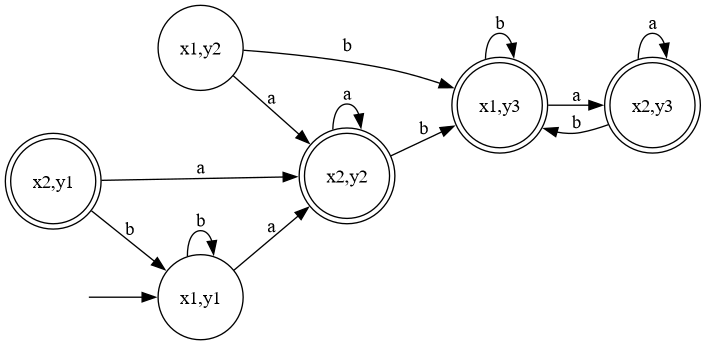

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# State diagram of the union of dfa1 and dfa2 above.
#
# Yes, this is the same as Figure 5 above.
# ─────────────────────────────────────────────────────────────────────────────

fig_num_7 = "7"
title_7 = "The union DFA created using the Python function (Unreduced)"
alt_text_7 = (
        "This is the same image as Figure 5 above. "
        "A complex Deterministic Finite Automaton (DFA) constructed as the product of two smaller DFAs. "
        "The machine has six composite states, labeled with pairs (xI, yJ), over the alphabet {a, b). "
        "The initial state is x1,y1. The machine accepts the union of the two component languages: strings that end in 'a' OR contain the substring 'ab'. "
        "The accepting states are all those where the x-component is x2 OR the y-component is y3. "
        "The transitions show the combined logic: for every input, the x-component updates its end-in-'a' status, "
        "and the y-component updates its contains-'ab' status simultaneously."
    )

dfa3_check.show(fig_num_7, title_7, alt_text_7)

This checks out to be the (not reduced) $DFA_{3}$ above.

### 2.3 Products

To take the product of two finite automata, say $DFA_{1} \cdot DFA_{2}$, you need to create another finite automata $DFA_{3}$, where the nodes of $DFA_{3}$ are of the form $x \times Y$, where $x$ is a node in $DFA_{1}$, and $Y$ is a (possibly empty) subset of the nodes from $DFA_{2}$. The transitions move the $x$ term within $DFA_{1}$ and the $y$ terms within $DFA_{2}$, and any time you're at a final state in $DFA_{1}$ you add the initial state of $DFA_{2}$ to $Y$ if it's not there already. The final states are those where $Y$ contains a  final state of $DFA_{2}$.

We can create a function for calculating this product for two DFAs.

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# Function that returns the product of two FAs.
#
# Running outside Jupyter:
#   python product.py
# ─────────────────────────────────────────────────────────────────────────────

def product(fa1, fa2, graph_size=None):
    """
    Returns a new FA representing the concatenation (product) of fa1 and fa2.
    The resulting FA accepts a string 'w' if it can be split into 'uv'
    where fa1 accepts 'u' and fa2 accepts 'v'.
    """
    if fa1.alphabet != fa2.alphabet:
        raise ValueError("Input FAs must have the same alphabet.")

    # 1. Start State
    # The initial state is (start1, empty_set).
    # Logic: We start in FA1. We only track states in FA2 (the set Y)
    # once we have potentially completed a word in FA1.
    start_y = frozenset()
    start_state_tuple = (fa1.start_state, start_y)

    # We will discover states via BFS to avoid generating unreachable states
    queue = [start_state_tuple]
    discovered_states = {start_state_tuple}
    transitions = {}
    final_states = set()

    # Helper to convert set to string for state naming
    def state_name(x, Y):
        # Sort Y to ensure consistent naming, e.g., "x1,{y1,y2}"
        y_str = "{" + ",".join(sorted(list(Y))) + "}" if Y else "\u00D8"
        return f"{x},{y_str}"

    processed_queue_index = 0
    while processed_queue_index < len(queue):
        current_tuple = queue[processed_queue_index]
        processed_queue_index += 1

        curr_x, curr_Y = current_tuple
        curr_name = state_name(curr_x, curr_Y)

        # Check if accepting:
        # The product machine accepts if the set Y contains an accept state from FA2.
        # This means we have successfully finished traversing FA2.
        if not curr_Y.isdisjoint(fa2.accept_states):
            final_states.add(curr_name)

        for symbol in fa1.alphabet:
            # 1. Move x in FA1
            next_x = fa1.transition_function[(curr_x, symbol)]

            # 2. Move all y in Y in FA2
            next_Y = set()
            for y in curr_Y:
                next_Y.add(fa2.transition_function[(y, symbol)])

            # 3. The "Product" Link
            # If the state we moved to in FA1 (next_x) is accepting,
            # it means we have found a valid prefix 'u'. We can now theoretically
            # start processing the rest of the string 'v' in FA2.
            # So, we inject the start state of FA2 into our set Y.
            if next_x in fa1.accept_states:
                next_Y.add(fa2.start_state)

            # Freeze the set to make it hashable for state tracking
            next_Y_frozen = frozenset(next_Y)
            next_tuple = (next_x, next_Y_frozen)
            next_name = state_name(next_x, next_Y_frozen)

            transitions[(curr_name, symbol)] = next_name

            if next_tuple not in discovered_states:
                discovered_states.add(next_tuple)
                queue.append(next_tuple)

    # Convert all discovered tuples to state names
    all_state_names = {state_name(x, y) for x, y in discovered_states}

    return FA(
        states=all_state_names,
        alphabet=fa1.alphabet,
        transition_function=transitions,
        start_state=state_name(start_state_tuple[0], start_state_tuple[1]),
        accept_states=final_states,
        graph_size=graph_size
    )

For example, if $DFA_{1}$ and $DFA_{2}$ are the two DFAs from Subsection 5.2.2, then their product is:

In [20]:
dfa_product = product(dfa1, dfa2, graph_size='8,5')


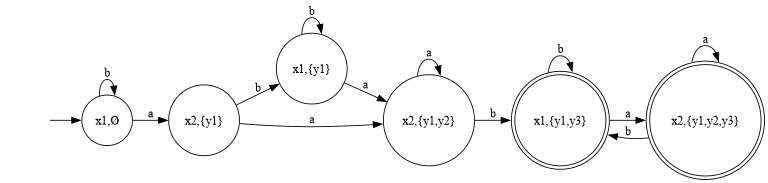

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# The state diagram of the product (concatenation) of dfa1 and dfa2 above.
# ─────────────────────────────────────────────────────────────────────────────

fig_num_8 = "8"
title_8 = "The product DFA of DFA1 concatenated with DFA2"
alt_text_8 = (
        "A product Deterministic Finite Automaton (DFA) constructed to recognize the language L1 followed by L2 (concatenation). "
        "The machine has six composite states, labeled as ordered pairs (xI, Y), over the alphabet {a, b}, where Y is a subset of DFA2 states. "
        "The initial state is (x1, Ø). "
        "The machine accepts strings 'uv' where DFA1 accepts 'u' and DFA2 accepts 'v'. "
        "The acceptance occurs when the second component (Y) contains the accept state of DFA2."
    )

dfa_product.show(fig_num_8, title_8, alt_text_8)

### 2.4 Kleene Star

To take the Kleene star of a DFA, say $DFA_{1}$, you need to create another finite automaton $DFA_{2}$ where the nodes of $DFA_{2}$ are subsets of the nodes from $DFA_{1}$. The transitions act on all the nodes from the subset, and any time the subset includes a final state from $DFA_{1}$, you add the initial state of $DFA_{1}$ if it's not already there. The start state of $DFA_{2}$ corresponds with the empty set, and transitions to the states to which the start state of $DFA_{1}$ transitions. The accepting states of $DFA_{2}$ are the start state, and any state the contains an accepting state of $DFA_{1}$ in its subset.

We can create a function for calculating the Kleene star of a DFA.

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# Function that returns the Kleene star of an FA.
#
# Running outside Jupyter:
#   python kleene_star.py
# ─────────────────────────────────────────────────────────────────────────────

def kleene_star(fa, graph_size=None):
    """
    Returns a new FA representing the Kleene Star of the input fa.
    """
    # 1. Start State is the Empty Set (conceptually)
    # We use frozenset() to represent sets of states as hashable keys
    start_set = frozenset()

    # We will discover states via BFS
    queue = [start_set]
    discovered_states = {start_set}
    transitions = {}

    # The empty set is ALWAYS an accept state in this construction (accepts lambda)
    accept_states = { "\u00D8" }

    # Helper to convert set to string for state naming
    def state_name(Y):
        if not Y:
            return "\u00D8"
        return "{" + ",".join(sorted(list(Y))) + "}"

    processed_queue_index = 0
    while processed_queue_index < len(queue):
        current_set = queue[processed_queue_index]
        processed_queue_index += 1

        curr_name = state_name(current_set)

        # Check acceptance condition from Section 5.2.4:
        # "Accepting states are the start state (handled above),
        # and any state that contains an accept state of DFA1."
        if not current_set.isdisjoint(fa.accept_states):
            accept_states.add(curr_name)

        # Calculate transitions
        for symbol in fa.alphabet:
            next_set_mutable = set()

            # Determine effective source states
            # If we are in the "Empty Set" start state, we behave as if
            # we are in the original FA's start state.
            sources = {fa.start_state} if not current_set else current_set

            # 1. Compute natural destinations
            for s in sources:
                if (s, symbol) in fa.transition_function:
                    next_set_mutable.add(fa.transition_function[(s, symbol)])

            # 2. The "Star" Logic (Injection)
            # If the destination contains ANY accept state from the original FA,
            # we add the original start state to the set.
            # (This allows us to begin a new word instance)
            if not next_set_mutable.isdisjoint(fa.accept_states):
                next_set_mutable.add(fa.start_state)

            next_set = frozenset(next_set_mutable)
            next_name = state_name(next_set)

            transitions[(curr_name, symbol)] = next_name

            if next_set not in discovered_states:
                discovered_states.add(next_set)
                queue.append(next_set)

    # Convert discovered tuples to state names
    all_state_names = {state_name(s) for s in discovered_states}

    return FA(
        states=all_state_names,
        alphabet=fa.alphabet,
        transition_function=transitions,
        start_state="\u00D8",
        accept_states=accept_states,
        graph_size=graph_size
    )

For example, suppose the DFA below is $DFA$:

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# DFA accepting strings containing "ab" with no "a" thereafter.
# ─────────────────────────────────────────────────────────────────────────────

dfa = FA(
    states={'x1', 'x2', 'x3', 'x4'},
    alphabet={'a', 'b'},
    transition_function={
        ('x1', 'a'): 'x2',
        ('x1', 'b'): 'x3',

        ('x2', 'a'): 'x2',
        ('x2', 'b'): 'x4',

        ('x3', 'a'): 'x3',
        ('x3', 'b'): 'x3',

        ('x4', 'a'): 'x3',
        ('x4', 'b'): 'x4'
    },
    start_state='x1',
    accept_states={'x4'}
)


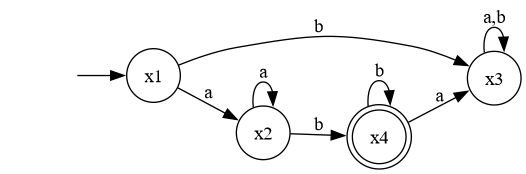

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# State diagram of DFA accepting strings containing "ab" with no "a" thereafter.
# ─────────────────────────────────────────────────────────────────────────────

fig_num_9 = "9"
title_9 = "Example DFA for Kleene star (L: strings containing 'ab', with no 'a' thereafter)"
alt_text_9 = (
        "A deterministic finite automaton (DFA) with four states, x1, x2, x3, and x4, over the alphabet {a, b}. "
        "State x1 is the initial state. State x4 is the single accepting state (double circle). "
        "The DFA recognizes strings that contain the substring 'ab' but rejects if the symbol 'a' follows the first 'ab'. "
        "State x1 is the start state. State x2 is reached after the first 'a'. "
        "State x3 is a non-accepting trap state that is reached if a 'b' is read too early or if an 'a' is read while in the accept state x4. "
        "From x4 (accepting): Input 'b' self-loops to x4, maintaining acceptance; Input 'a' transitions to the trap state x3, ending the acceptance chain."
    )

dfa.show(fig_num_9, title_9, alt_text_9)

The Kleene star of $DFA$ would be:

In [26]:
dfa_star = kleene_star(dfa, graph_size='8,5')


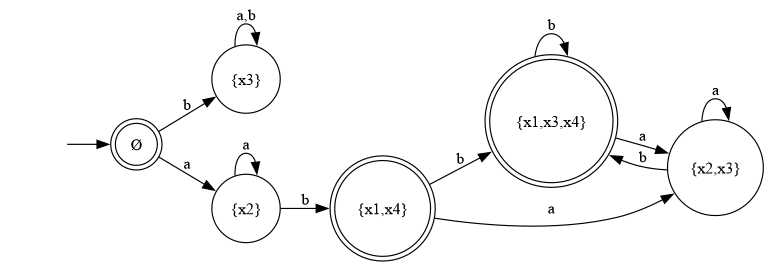

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# State diagram of Kleene star of DFA accepting strings containing "ab" 
# with no "a" thereafter.
# ─────────────────────────────────────────────────────────────────────────────

fig_num_10 = "10"
title_10 = "The Kleene star of the example DFA (L*)"
alt_text_10 = (
        "A complex Deterministic Finite Automaton (DFA) constructed via the Kleene Star operation on the base language L. "
        "The resulting DFA recognizes the language L star, which is zero or more concatenations of the original language. "
        "The machine has six composite states derived from the power set of the original DFA's states. "
        "The initial state is the empty set (Ø), which is also an accept state (to accept the empty string, lambda). "
        "Accepting states are the empty set and any composite state that includes the original DFA's accept state (x4). "
        "The transitions embody the star operation: when a composite state transitions to a set containing x4, "
        "the original start state (x1) is automatically injected into the next state set, enabling the machine to immediately start recognizing the next word instance in the concatenation."
    )

dfa_star.show(fig_num_10, title_10, alt_text_10)

That's it! Now that we can generate the basic building blocks (the empty string and single characters), and how we build with them (unions, products, and stars) we can generate a DFA that recognizes the languages generated by any given regular expression.

## 4. References and Further Reading

* Introduction to Computer Theory (Second Edition) by Daniel I.A. Cohen

  *Chapter 7 - Kleene's Theorem*

* Automata Theory, Languages, and Computation (Third Edition) by Hopcroft, Motwani, and Ullman

  *Section 3.2 - Finite Automata and Regular Expressions*

* Introduction to the Theory of Computation (Third Edition) by Michael Sipser
  
  *Section 1.2 - Nondeterminism,* *Section 1.3 - Regular Expressions*

* <a href="https://en.wikipedia.org/wiki/Thompson%27s_construction" target="_blank">"Thompson's Construction"</a> is licensed under <a href="http://creativecommons.org/licenses/by-sa/4.0" target="_blank">CC BY-SA 4.0</a>

## 5. Practice Problems

As in Chapters 3 and 4, there are no separate programming problems for this chapter, as programming is integrated with the practice problems below.

Suppose $DFA_{3}$ is:

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# DFA accepting strings that end with an "a".
# ─────────────────────────────────────────────────────────────────────────────

dfa3 = Digraph()
dfa3.attr(rankdir='LR') # This specifies the diagram should go left to right

# Start arrow
dfa3.node('', shape='none')
dfa3.edge('', 'x1')

# States
with dfa3.subgraph() as start:
  start.attr(rank='same')
  start.node('x1', shape='circle')
with dfa3.subgraph() as accept:
  accept.attr(rank='same')
  accept.node('x2', shape='doublecircle')

# Transitions
dfa3.edge('x1', 'x2', label='a')
dfa3.edge('x1', 'x1', label='b')
dfa3.edge('x2', 'x2', label='a')
dfa3.edge('x2', 'x1', label='b')


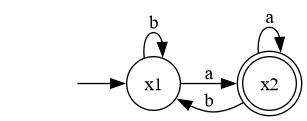

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# State diagram of DFA accepting strings that end with an "a".
# ─────────────────────────────────────────────────────────────────────────────

fig_num_11 = "11"
title_11 = "Finite automaton accepting strings that end with 'a'"
alt_text_11 = (
    "A deterministic finite automaton (DFA) with two states, x1 and x2, over the alphabet {a, b}. "
    "State x1 is the initial, non-accepting state. State x2 is the accepting state (double circle). "
    "The DFA recognizes all strings that end with the character 'a'. "
    "Transitions are defined as follows: "
    "From state x1, input 'a' transitions to the accepting state x2, and input 'b' self-loops to x1. "
    "From state x2 (accepting), input 'a' self-loops to x2, maintaining acceptance, and input 'b' transitions back to the non-accepting state x1."
)

display_graph_with_caption(dfa3, fig_num_11, title_11, alt_text_11)

And $DFA_{4}$ is:

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# DFA accepting strings that contain an "a".
# ─────────────────────────────────────────────────────────────────────────────

dfa4 = Digraph()
dfa4.attr(rankdir='LR') # This specifies the diagram should go left to right

# Start arrow
dfa4.node('', shape='none')
dfa4.edge('', 'y1')

# States
with dfa4.subgraph() as start:
  start.attr(rank='same')
  start.node('y1', shape='circle')
with dfa4.subgraph() as accept:
  accept.attr(rank='same')
  accept.node('y2', shape='doublecircle')

# Transitions
dfa4.edge('y1', 'y2', label='a')
dfa4.edge('y1', 'y1', label='b')
dfa4.edge('y2', 'y2', label='a,b')


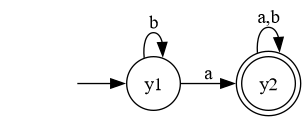

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# State diagram of DFA accepting strings that contain an "a".
# ─────────────────────────────────────────────────────────────────────────────

fig_num_12 = "12"
title_12 = "Finite automaton accepting strings that contain an 'a'"
alt_text_12 = (
    "A deterministic finite automaton (DFA) with two states, y1 and y2, over the alphabet {a, b}. "
    "State y1 is the initial, non-accepting state. State y2 is the single accepting state (double circle). "
    "The DFA recognizes all strings that contain at least one instance of the symbol 'a'. "
    "Transitions are defined as follows: "
    "From state y1, input 'a' transitions to the accepting state y2, and input 'b' self-loops to y1. "
    "From state y2 (accepting), both input 'a' and input 'b' self-loop to y2, ensuring acceptance is maintained once 'a' has been read."
)

# Use the global utility function
display_graph_with_caption(dfa4, fig_num_12, title_12, alt_text_12)

### 5.1 Implementing FA Classes

Implement the DFAs diagrammed above ($DFA_{3}$ and $DFA_{4}$) as FA classes.

In [ ]:
dfa3_fa = FA(
    # YOUR CODE HERE
)

dfa3_fa.show()

In [ ]:
dfa4_fa = FA(
    # YOUR CODE HERE
)

dfa4_fa.show()

### 5.2 The Union of FAs

Find the union of $DFA_{3}$ and $DFA_{4}$, $DFA_{3} + DFA_{4}$, using the *union* function defined above. What language does it recognize?

### 5.3 The Concatenation of FAs

Find the concatenation of $DFA_{3}$ and $DFA_{4}$, $DFA_{3} \cdot DFA_{4}$, using the *product* function defined above. What language does it recognize?

### 5.4 The Star of an FA

Find the Kleene star of $DFA_{3}$, $DFA_{3}^{*}$, using the *kleene_star* function defined above. What language does it recognize?